In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from torch.utils.data import Dataset, DataLoader
from rdkit import Chem
import selfies  # Ensure you have installed selfies (pip install selfies)

In [2]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import PandasTools
from tqdm import tqdm

# Load QM9 CSV file (make sure qm9.csv is in the same folder)
df = pd.read_csv('qm9.csv')

# Ensure it has a column named 'smiles'
assert 'smiles' in df.columns, "CSV must have a 'smiles' column."

# Convert SMILES to RDKit Mol objects
PandasTools.AddMoleculeColumnToFrame(df, smilesCol='smiles')

# Function to detect potential FLPs with carbon reuse features
def is_potential_flp(mol):
    if mol is None:
        return False

    has_b_or_base = False
    carbon_count = 0
    oxygen_count = 0

    for atom in mol.GetAtoms():
        atomic_num = atom.GetAtomicNum()
        if atomic_num in [5, 7, 15]:  # Boron, Nitrogen, Phosphorus
            has_b_or_base = True
        elif atomic_num == 6:  # Carbon
            carbon_count += 1
        elif atomic_num == 8:    # Oxygen
            oxygen_count += 1

    return has_b_or_base and carbon_count >= 1 and oxygen_count >= 1

# Apply filter to dataframe
print("Filtering QM9 molecules for potential FLP candidates...")
filtered_df = df[df['ROMol'].apply(is_potential_flp)].copy()
print(filtered_df)

Filtering QM9 molecules for potential FLP candidates...
            mol_id               smiles         A         B        C      mu  \
11          gdb_12               C(=O)N  73.84720  11.34793  9.83639  3.7286   
18          gdb_19              CC(=O)N  10.78886   9.27509  5.14977  3.6367   
19          gdb_20            C(=O)(N)N  11.14750  10.36388  5.42091  3.4869   
26          gdb_27             C(=O)C#N  67.88408   5.00823  4.66413  2.3112   
33          gdb_34              C(C#N)O  35.93172   4.83443  4.37827  4.6788   
...            ...                  ...       ...       ...      ...     ...   
133871  gdb_133872    C1C2C3OC4CN2C13C4   3.17344   2.01595  1.96622  0.8088   
133873  gdb_133874    C1N2C3CC4CC2C13O4   3.17845   1.97751  1.91188  0.6916   
133880  gdb_133881  C1C2C3C4C5OC14C5N23   3.59483   2.19899  1.90423  1.6637   
133881  gdb_133882  C1N2C3C2C2C4OC12C34   3.65648   2.14237  1.90439  1.2976   
133884  gdb_133885  C1N2C3C4C5OC13C2C45   3.64015   2.21764  1.9

In [3]:
from rdkit import Chem
from rdkit.Chem import Descriptors, AllChem
from rdkit.Chem.rdPartialCharges import ComputeGasteigerCharges
import numpy as np
import pandas as pd

def extract_fast_flp_features(mol):
    if mol is None:
        return {}

    features = {}

    try:
        # Gasteiger charges
        ComputeGasteigerCharges(mol)
        charges = [float(atom.GetProp('_GasteigerCharge')) for atom in mol.GetAtoms()]
        features['max_charge'] = max(charges)
        features['min_charge'] = min(charges)
        features['charge_diff'] = features['max_charge'] - features['min_charge']
    except:
        features['max_charge'] = None
        features['min_charge'] = None
        features['charge_diff'] = None

    # 2D descriptors (fast and informative)
    features.update({
        'mol_wt': Descriptors.MolWt(mol),
        'TPSA': Descriptors.TPSA(mol),
        'logP': Descriptors.MolLogP(mol),
        'num_rotatable_bonds': Descriptors.NumRotatableBonds(mol),
        'num_rings': mol.GetRingInfo().NumRings(),
        'num_H_donors': Descriptors.NumHDonors(mol),
        'num_H_acceptors': Descriptors.NumHAcceptors(mol),
    })

    # 3D conformer (non-optimized)
    try:
        mol3D = Chem.AddHs(mol)
        AllChem.EmbedMolecule(mol3D, AllChem.ETKDGv3())
        conf = mol3D.GetConformer()
        coords = np.array([list(conf.GetAtomPosition(i)) for i in range(mol3D.GetNumAtoms())])
        dist_matrix = np.linalg.norm(coords[:, None, :] - coords[None, :, :], axis=-1)
        np.fill_diagonal(dist_matrix, np.inf)
        features['min_3D_dist'] = dist_matrix.min()
        features['max_3D_dist'] = dist_matrix.max()
    except:
        features['min_3D_dist'] = None
        features['max_3D_dist'] = None

    return features
sampled_df = filtered_df.sample(n=10000, random_state=42)
features = sampled_df['ROMol'].apply(extract_fast_flp_features)
features_df = pd.DataFrame(features.tolist())

In [4]:
print(features_df.columns.tolist())
print(sampled_df)

['max_charge', 'min_charge', 'charge_diff', 'mol_wt', 'TPSA', 'logP', 'num_rotatable_bonds', 'num_rings', 'num_H_donors', 'num_H_acceptors', 'min_3D_dist', 'max_3D_dist']
            mol_id                  smiles        A        B        C      mu  \
58032    gdb_58033       CN(C)C(C#N)C(N)=O  1.99051  1.51311  1.04321  6.3308   
29485    gdb_29486        Cc1coc2c1[nH]cc2  3.26420  1.64221  1.10001  2.6288   
31729    gdb_31730        CNc1c[nH]c(n1)OC  4.52275  0.95569  0.79956  1.3553   
127428  gdb_127429       Cc1c(c(n(n1)C)O)O  2.37803  1.60839  0.97342  2.0251   
29113    gdb_29114  c1c(oc(=O)c(=O)[nH]1)O  3.14131  1.48117  1.00656  4.9426   
...            ...                     ...      ...      ...      ...     ...   
72982    gdb_72983        NC12CNC1C2(O)C#N  2.72535  1.54708  1.21460  6.3684   
62531    gdb_62532       CC1(N)C(OC1=N)C#C  2.45750  1.40857  1.17357  1.3429   
73937    gdb_73938        CC1=C(CNC1=O)C#C  3.12372  1.29556  0.92625  3.5228   
22711    gdb_22712 

In [5]:
# --------------------
# Data Preprocessing: Convert SMILES to tokenized SELFIES
# --------------------

class MolecularSELFIESDataset(Dataset):
    def __init__(self, smiles_list):
        self.smiles = smiles_list
        # Convert each SMILES to its tokenized SELFIES representation
        self.selfies_tokens_list = [self.smiles_to_selfies_tokens(smi) for smi in self.smiles]
        
        # Build vocabulary from all tokens (reserve index 0 for padding)
        all_tokens = [token for tokens in self.selfies_tokens_list for token in tokens]
        unique_tokens = sorted(set(all_tokens))
        self.token_to_idx = {token: idx + 1 for idx, token in enumerate(unique_tokens)}
        self.idx_to_token = {idx: token for token, idx in self.token_to_idx.items()}
        
        # Determine maximum sequence length for padding
        self.max_seq_len = max(len(tokens) for tokens in self.selfies_tokens_list)
        # Vocabulary size includes padding token (index 0)
        self.vocab_size = len(self.token_to_idx) + 1
        
        # Convert token sequences to fixed-length one-hot encoded vectors (flattened)
        self.encoded_data = []
        for tokens in self.selfies_tokens_list:
            # Convert tokens to indices and pad the sequence
            token_indices = [self.token_to_idx[token] for token in tokens]
            padded = token_indices + [0] * (self.max_seq_len - len(token_indices))
            # One-hot encode the padded sequence (shape: [max_seq_len, vocab_size])
            one_hot = np.eye(self.vocab_size)[padded]
            # Flatten to a 1D vector
            one_hot_flat = one_hot.flatten()
            self.encoded_data.append(one_hot_flat)
    
    def smiles_to_selfies_tokens(self, smiles):
        """Convert SMILES string to a list of SELFIES tokens."""
        try:
            selfies_str = selfies.encoder(smiles)
            # Explicitly convert the output to a list if it's not already
            tokens = list(selfies.split_selfies(selfies_str))
            return tokens
        except Exception:
            return []  # Return empty token list for invalid molecules
    
    def __len__(self):
        return len(self.encoded_data)
    
    def __getitem__(self, idx):
        return torch.tensor(self.encoded_data[idx], dtype=torch.float32)

# Extract SMILES list and create the dataset and dataloader
smiles_list = sampled_df["smiles"].dropna().tolist()  # Remove NaN values
dataset = MolecularSELFIESDataset(smiles_list)
data_loader = DataLoader(dataset, batch_size=64, shuffle=True)

print(f"✅ Dataset successfully loaded with {len(dataset)} molecules for training.")
print(f"Vocabulary size: {dataset.vocab_size}, Sequence length: {dataset.max_seq_len}")

# Data dimension: each molecule is represented as a flattened vector
data_dim = dataset.max_seq_len * dataset.vocab_size

✅ Dataset successfully loaded with 10000 molecules for training.
Vocabulary size: 29, Sequence length: 21


In [6]:
# --------------------
# WGAN Architecture
# --------------------
latent_dim = 128

class Generator(nn.Module):
    def __init__(self, latent_dim, output_dim):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 1024),
            nn.ReLU(),
            nn.Linear(1024, output_dim),
            nn.Tanh()
        )
    def forward(self, z):
        return self.model(z)
    
class Discriminator(nn.Module):
    def __init__(self, input_dim):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, 1)
        )
    def forward(self, x):
        return self.model(x)

# Initialize models
generator = Generator(latent_dim=latent_dim, output_dim=data_dim)
discriminator = Discriminator(input_dim=data_dim)

def compute_gradient_penalty(D, real_samples, fake_samples):
    alpha = torch.rand(real_samples.size(0), 1)
    alpha = alpha.expand_as(real_samples)
    interpolates = alpha * real_samples + (1 - alpha) * fake_samples
    interpolates.requires_grad_(True)
    d_interpolates = D(interpolates)
    gradients = torch.autograd.grad(
        outputs=d_interpolates,
        inputs=interpolates,
        grad_outputs=torch.ones_like(d_interpolates),
        create_graph=True,
        retain_graph=True
    )[0]
    gradient_penalty = ((gradients.norm(2, dim=1) - 1) ** 2).mean()
    return gradient_penalty

Epoch 0, Loss D: 0.23267579078674316, Loss G: -0.990987241268158


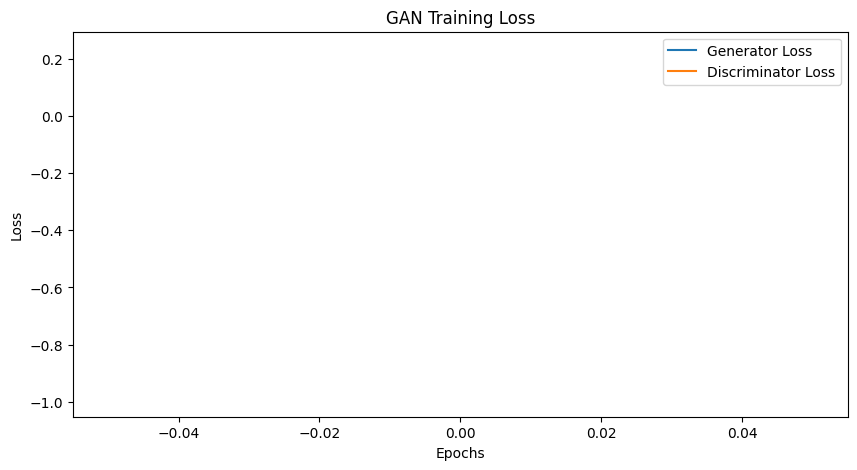

Epoch 50, Loss D: -0.9813016653060913, Loss G: -0.957361102104187


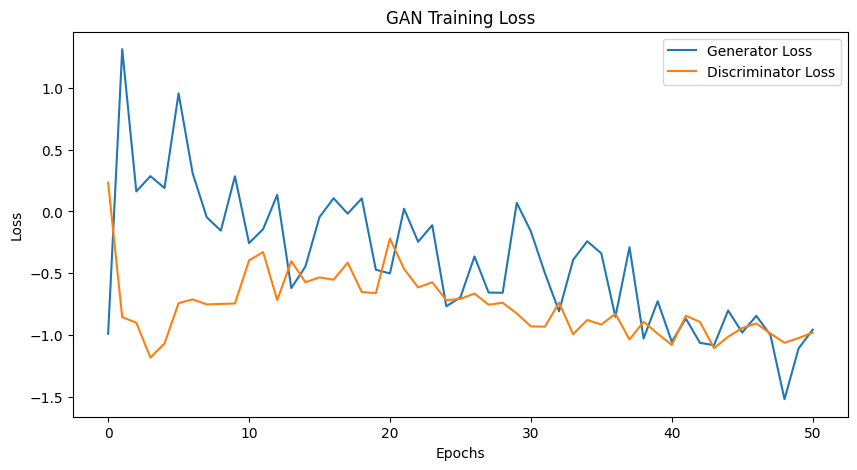

Epoch 100, Loss D: -0.9331636428833008, Loss G: -1.3886185884475708


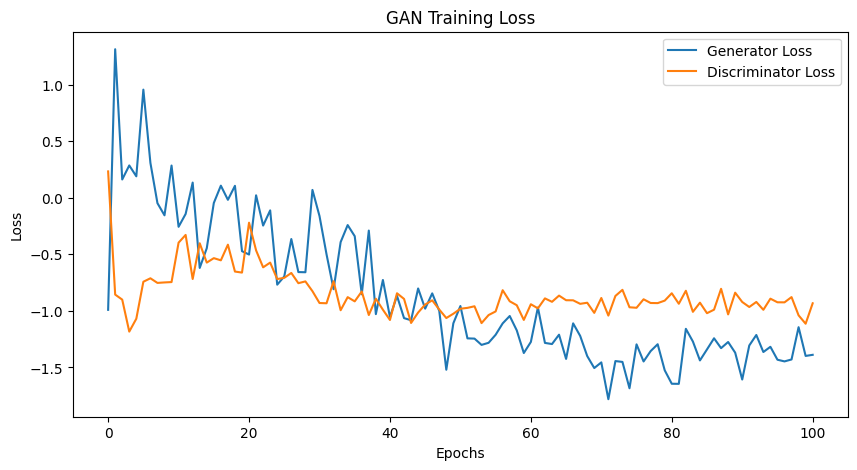

Epoch 150, Loss D: -1.1158294677734375, Loss G: -0.5220699310302734


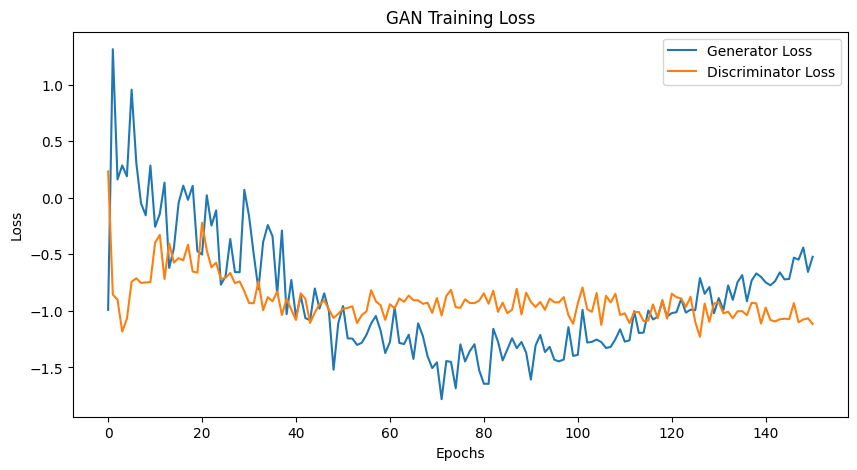

Epoch 200, Loss D: -1.110305905342102, Loss G: -0.16167494654655457


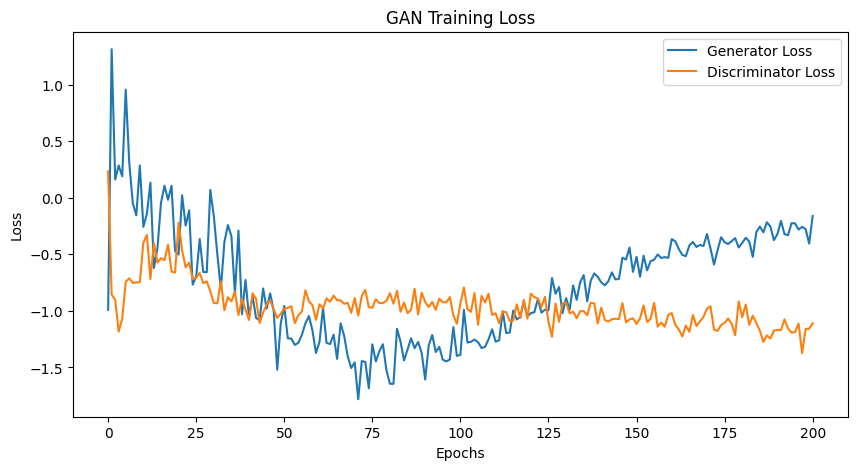

Epoch 250, Loss D: -1.1823450326919556, Loss G: -0.1501147598028183


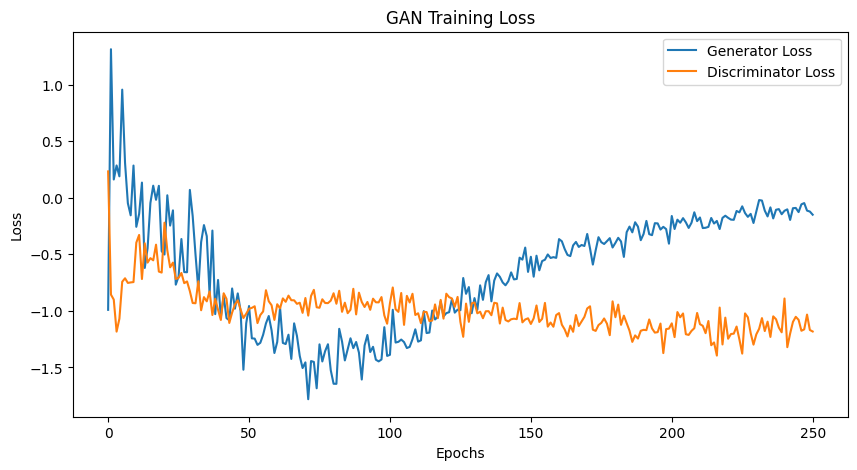

Epoch 300, Loss D: -1.228400707244873, Loss G: -0.07250729203224182


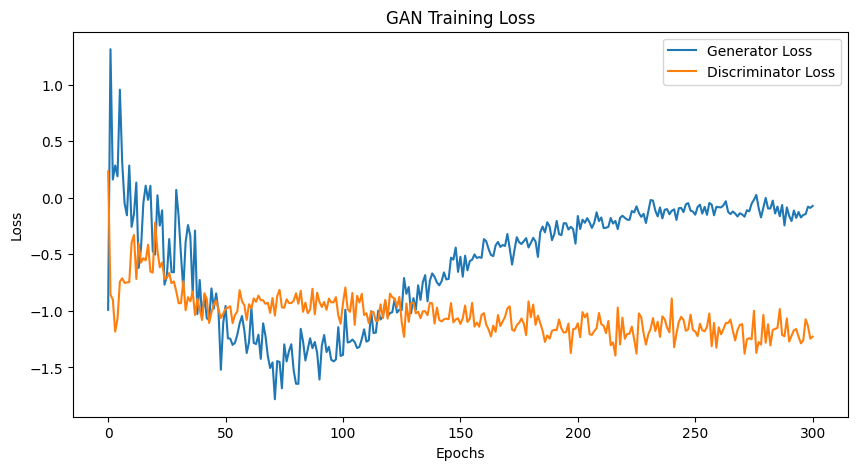

Epoch 350, Loss D: -1.2844725847244263, Loss G: -0.32556378841400146


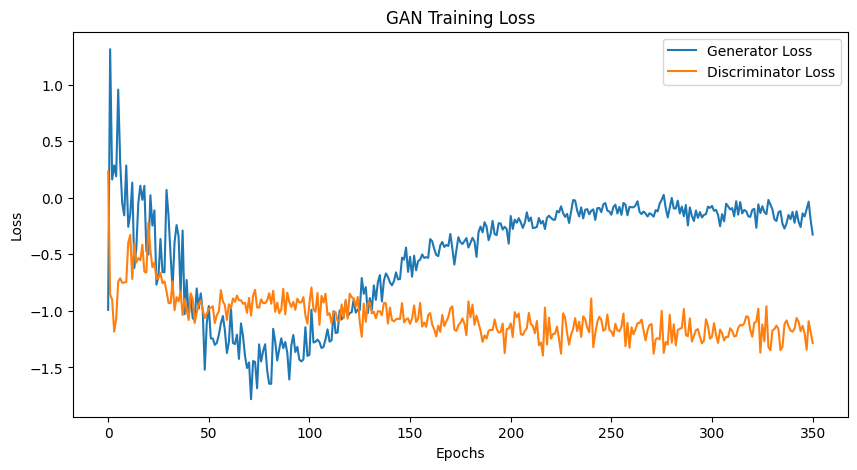

Epoch 400, Loss D: -1.2422187328338623, Loss G: -0.3012302815914154


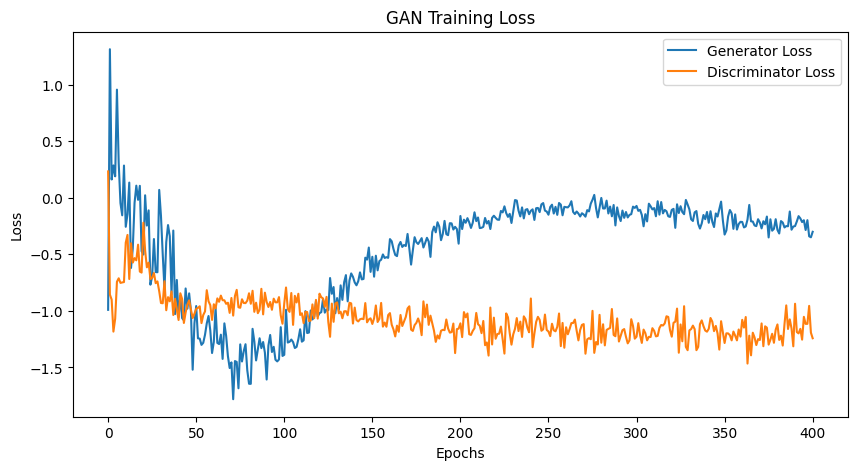

Epoch 450, Loss D: -1.0501964092254639, Loss G: -0.28265756368637085


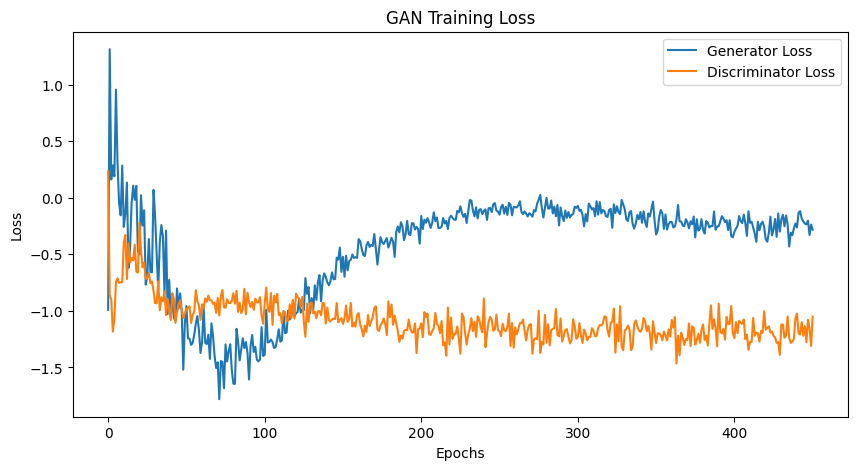

In [7]:
# --------------------
# Training Loop
# --------------------
optimizer_G = optim.Adam(generator.parameters(), lr=0.0006, betas=(0.5, 0.9))
optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0004, betas=(0.5, 0.9))

n_epochs = 500  # Adjust number of epochs as needed
lambda_gp = 10
losses_G, losses_D = [], []

def plot_losses():
    plt.figure(figsize=(10, 5))
    plt.plot(losses_G, label='Generator Loss')
    plt.plot(losses_D, label='Discriminator Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('GAN Training Loss')
    plt.show()

for epoch in range(n_epochs):
    for real_samples in data_loader:
        real_samples = real_samples.float()
        batch_size = real_samples.size(0)
        
        # Train Discriminator
        optimizer_D.zero_grad()
        z = torch.randn(batch_size, latent_dim)
        fake_samples = generator(z).detach()
        loss_D_real = -torch.mean(discriminator(real_samples))
        loss_D_fake = torch.mean(discriminator(fake_samples))
        gradient_penalty = compute_gradient_penalty(discriminator, real_samples, fake_samples)
        loss_D = loss_D_real + loss_D_fake + lambda_gp * gradient_penalty
        loss_D.backward()
        optimizer_D.step()
        
        # Train Generator
        optimizer_G.zero_grad()
        z = torch.randn(batch_size, latent_dim)
        fake_samples = generator(z)
        loss_G = -torch.mean(discriminator(fake_samples))
        loss_G.backward()
        optimizer_G.step()
        
    losses_G.append(loss_G.item())
    losses_D.append(loss_D.item())
    
    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss D: {loss_D.item()}, Loss G: {loss_G.item()}")
        plot_losses()

In [8]:
# --------------------
# Reconstructing Molecular Representations
# --------------------
def reconstruct_selfies(gen_output, max_seq_len, vocab_size, idx_to_token):
    """
    Convert a GAN-generated flattened vector into a SELFIES string.
    
    Args:
        gen_output (np.array): Flattened output vector from the generator.
        max_seq_len (int): Maximum sequence length used in the dataset.
        vocab_size (int): Vocabulary size used in one-hot encoding.
        idx_to_token (dict): Mapping from indices to SELFIES tokens.
    
    Returns:
        str: Reconstructed SELFIES string.
    """
    # Reshape the output vector into [max_seq_len, vocab_size]
    reshaped = gen_output.reshape(max_seq_len, vocab_size)
    # Discretize: choose the token with maximum value in each position
    token_indices = np.argmax(reshaped, axis=1)
    # Remove padding tokens (assumed index 0)
    token_indices = [idx for idx in token_indices if idx != 0]
    # Map indices back to tokens
    tokens = [idx_to_token.get(idx, '') for idx in token_indices]
    selfies_str = "".join(tokens)
    return selfies_str

In [9]:
# 🔁 Reinforcement Learning Loop
import torch
from rdkit import Chem
from rdkit.Chem import AllChem, rdMolTransforms
import numpy as np
import selfies
import matplotlib.pyplot as plt

# SMARTS patterns for Lewis base and acid
lewis_base_smarts = Chem.MolFromSmarts("[N,P;!H0]")
lewis_acid_smarts = Chem.MolFromSmarts("[B,Al;X3]")

avg_rewards = []
best_reward = -np.inf
no_improve = 0
patience = 100  # Stop if no improvement in 100 epochs

generator.train()
optimizer_G = torch.optim.Adam(generator.parameters(), lr=1e-4)
batch_size = 32
epochs = 1000  # Set high, rely on early stopping

for epoch in range(epochs):
    z = torch.randn(batch_size, latent_dim, requires_grad=True)
    gen_output = generator(z)

    rewards = []

    for i in range(batch_size):
        gen_vec = gen_output[i].detach().cpu().numpy()
        selfies_str = reconstruct_selfies(
            gen_vec,
            dataset.max_seq_len,
            dataset.vocab_size,
            dataset.idx_to_token
        )

        try:
            smiles_str = selfies.decoder(selfies_str)
        except:
            smiles_str = ""

        if smiles_str == "":
            rewards.append(-1.0)
            continue

        mol = Chem.MolFromSmiles(smiles_str)
        if mol is None:
            rewards.append(-1.0)
            continue

        features = extract_fast_flp_features(mol)
        base_reward = 0
        if features['charge_diff'] is not None and features['min_3D_dist'] is not None:
            base_reward += (
                2.0 * features['charge_diff'] +
                1.0 / (features['min_3D_dist'] + 1e-3) +
                0.2 * features['TPSA']
            )

        try:
            mol3D = Chem.AddHs(mol)
            AllChem.EmbedMolecule(mol3D, AllChem.ETKDGv3())
            conf = mol3D.GetConformer()

            base_matches = mol3D.GetSubstructMatches(lewis_base_smarts)
            acid_matches = mol3D.GetSubstructMatches(lewis_acid_smarts)

            if base_matches and acid_matches:
                min_AB_dist = float("inf")
                for b in base_matches:
                    for a in acid_matches:
                        d = rdMolTransforms.GetBondLength(conf, b[0], a[0])
                        min_AB_dist = min(min_AB_dist, d)
                base_reward += 3.0 / (min_AB_dist + 1e-3)
        except:
            pass

        rewards.append(base_reward)

    epoch_avg = np.mean(rewards)
    avg_rewards.append(epoch_avg)

    # --- Early Stopping Check ---
    if epoch_avg > best_reward:
        best_reward = epoch_avg
        no_improve = 0
    else:
        no_improve += 1

    if no_improve >= patience:
        print(f"\n🚨 Early stopping at epoch {epoch} | Best Reward: {best_reward:.4f}")
        break

    # Dummy loss and generator update
    z = torch.randn(batch_size, latent_dim, requires_grad=True)
    fake_samples = generator(z)
    dummy_loss = fake_samples.mean()
    optimizer_G.zero_grad()
    dummy_loss.backward()
    optimizer_G.step()

    if epoch % 10 == 0:
        print(f"Epoch {epoch} | Avg Reward = {epoch_avg:.4f} | Best = {best_reward:.4f} | No improve = {no_improve}")

Epoch 0 | Avg Reward = 10.0574 | Best = 10.0574 | No improve = 0
Epoch 10 | Avg Reward = 9.9725 | Best = 10.4496 | No improve = 6
Epoch 20 | Avg Reward = 10.5570 | Best = 10.5570 | No improve = 0
Epoch 30 | Avg Reward = 8.9107 | Best = 10.5570 | No improve = 10
Epoch 40 | Avg Reward = 7.7860 | Best = 10.5570 | No improve = 20
Epoch 50 | Avg Reward = 9.0060 | Best = 10.5570 | No improve = 30
Epoch 60 | Avg Reward = 7.4955 | Best = 10.5570 | No improve = 40
Epoch 70 | Avg Reward = 9.8986 | Best = 10.5570 | No improve = 50
Epoch 80 | Avg Reward = 9.2258 | Best = 10.5570 | No improve = 60
Epoch 90 | Avg Reward = 7.7677 | Best = 10.5570 | No improve = 70
Epoch 100 | Avg Reward = 8.8551 | Best = 10.5570 | No improve = 80
Epoch 110 | Avg Reward = 7.3029 | Best = 10.5570 | No improve = 90

🚨 Early stopping at epoch 120 | Best Reward: 10.5570


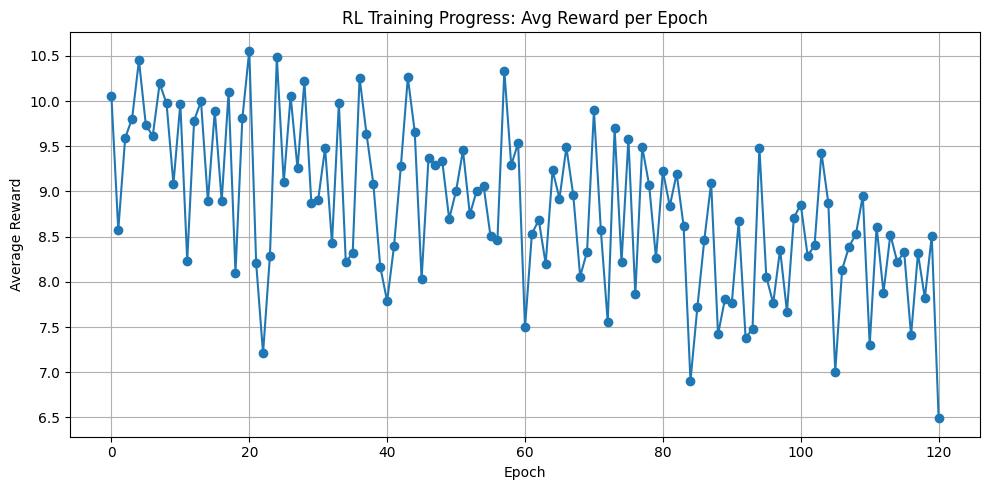

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(avg_rewards, marker='o', linestyle='-')
plt.xlabel("Epoch")
plt.ylabel("Average Reward")
plt.title("RL Training Progress: Avg Reward per Epoch")
plt.grid(True)
plt.tight_layout()
plt.show()

In [11]:
n_samples = 100  # Number of molecules to generate
generator.eval()  # Set the generator to evaluation mode

generated_smiles_list = set()

with torch.no_grad():
    # Generate a batch of latent vectors
    z = torch.randn(n_samples, latent_dim)
    # Generate samples from the generator
    gen_samples = generator(z).detach().cpu().numpy()
    
    # For each generated sample, reconstruct the SELFIES and convert to SMILES
    for gen_sample in gen_samples:
        selfies_str = reconstruct_selfies(gen_sample, dataset.max_seq_len, dataset.vocab_size, dataset.idx_to_token)
        smiles_str = selfies.decoder(selfies_str)
        if smiles_str != "":
            generated_smiles_list.add(smiles_str)

# Print all generated SMILES
for i, smi in enumerate(generated_smiles_list, 1):
    print(f"Molecule {i}: {smi}")

Molecule 1: CC1CN1CNCOCC
Molecule 2: O=C1CCC1C2CC2=O
Molecule 3: C1C2CC1(CC)OC2=O
Molecule 4: C1C(C)(OO1)C=O
Molecule 5: C1=C=C(C=C1)OC(O)N
Molecule 6: CC=CCC1C=CCNN1COC
Molecule 7: OCC1CCCCCN1C#N
Molecule 8: CC(=O)CCCNCC
Molecule 9: O=CCOC1N=C1C=O
Molecule 10: CC1CC1C(C#N)C#N
Molecule 11: CC=C(CCCC)CC
Molecule 12: OC(O)CCCNC#N
Molecule 13: CCCCCC(NC)NC=N
Molecule 14: OCC1(O)NC(=O)C1O
Molecule 15: N=COCCC(O)C=O
Molecule 16: CC(CC)CCCCC
Molecule 17: NC(=O)C12CC3CC1C23
Molecule 18: CCCCCCNC(=O)C#N
Molecule 19: N=COCC1C2C3CNC3C12
Molecule 20: CCN(CC)CO
Molecule 21: CNCCCCC=O
Molecule 22: CN1CNC1O
Molecule 23: O=CCCOCCCCC
Molecule 24: C=CC=CC=NOC
Molecule 25: N#CCCNCN
Molecule 26: CCC1CCCC=C1
Molecule 27: C1C(=O)NC1C=O
Molecule 28: C1C(C23)C2C13C#N
Molecule 29: O1CC2NC1(CC)C2=O
Molecule 30: CCC12CCC1N2CC
Molecule 31: OC12C3C1CC3C2C#N
Molecule 32: CNCOC1CC1C
Molecule 33: O=C1CCNC1CCC
Molecule 34: CN=CNC(=NCC)C
Molecule 35: CCCC(C)(C=O)C#N
Molecule 36: CNCC1NC1(C2)CO2
Molecule 37: CCC=CCCN=C

In [12]:
from rdkit import Chem

def validate_smiles(smiles_str):
    """
    Validate a SMILES string using RDKit.
    
    Args:
        smiles_str (str): The SMILES string to validate.
        
    Returns:
        bool: True if the SMILES is valid, False otherwise.
    """
    try:
        # Convert the SMILES string into an RDKit molecule
        mol = Chem.MolFromSmiles(smiles_str)
        if mol is None:
            return False
        
        # Optional: sanitize the molecule to catch any additional issues
        Chem.SanitizeMol(mol)
        return True
    except Exception as e:
        # If any exception occurs, the SMILES is considered invalid
        return False
for i, smi in enumerate(generated_smiles_list, 1):
    print(smi)
    if validate_smiles(smi):
        print("The generated SMILES is valid!")
    else:
        print("The generated SMILES is invalid.")


CC1CN1CNCOCC
The generated SMILES is valid!
O=C1CCC1C2CC2=O
The generated SMILES is valid!
C1C2CC1(CC)OC2=O
The generated SMILES is valid!
C1C(C)(OO1)C=O
The generated SMILES is valid!
C1=C=C(C=C1)OC(O)N
The generated SMILES is valid!
CC=CCC1C=CCNN1COC
The generated SMILES is valid!
OCC1CCCCCN1C#N
The generated SMILES is valid!
CC(=O)CCCNCC
The generated SMILES is valid!
O=CCOC1N=C1C=O
The generated SMILES is valid!
CC1CC1C(C#N)C#N
The generated SMILES is valid!
CC=C(CCCC)CC
The generated SMILES is valid!
OC(O)CCCNC#N
The generated SMILES is valid!
CCCCCC(NC)NC=N
The generated SMILES is valid!
OCC1(O)NC(=O)C1O
The generated SMILES is valid!
N=COCCC(O)C=O
The generated SMILES is valid!
CC(CC)CCCCC
The generated SMILES is valid!
NC(=O)C12CC3CC1C23
The generated SMILES is valid!
CCCCCCNC(=O)C#N
The generated SMILES is valid!
N=COCC1C2C3CNC3C12
The generated SMILES is valid!
CCN(CC)CO
The generated SMILES is valid!
CNCCCCC=O
The generated SMILES is valid!
CN1CNC1O
The generated SMILES is v

CC1CN1CNCOCC


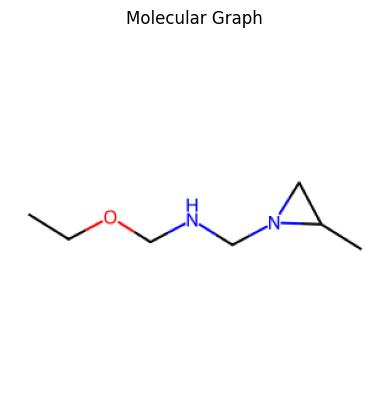

O=C1CCC1C2CC2=O


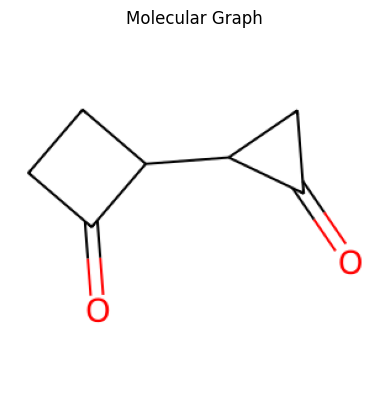

C1C2CC1(CC)OC2=O


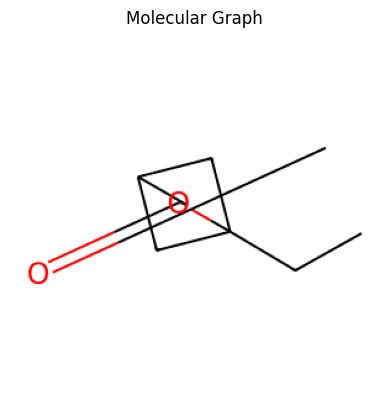

C1C(C)(OO1)C=O


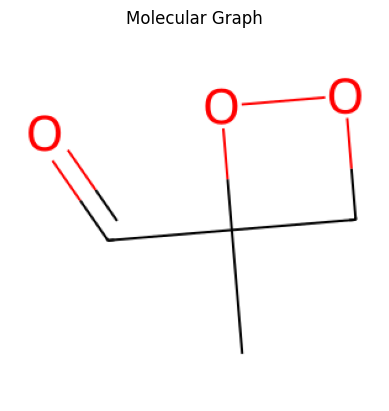

C1=C=C(C=C1)OC(O)N


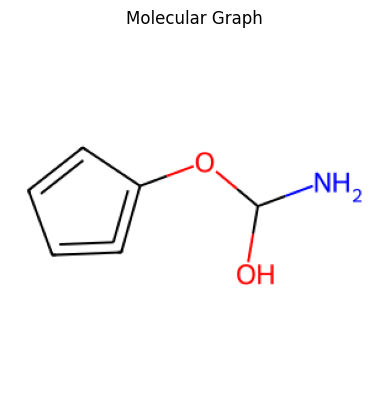

CC=CCC1C=CCNN1COC


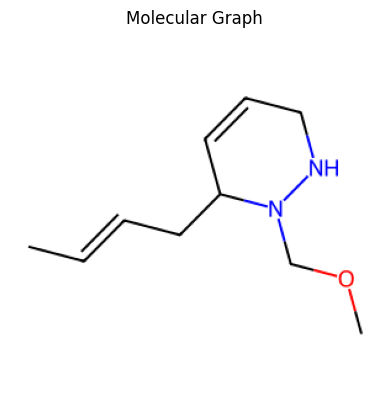

OCC1CCCCCN1C#N


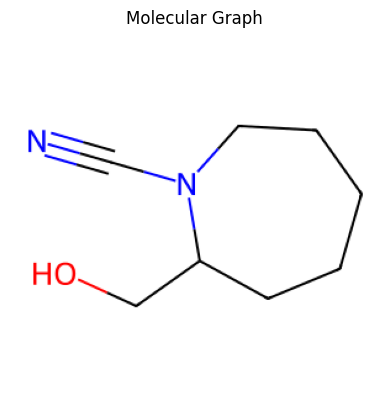

CC(=O)CCCNCC


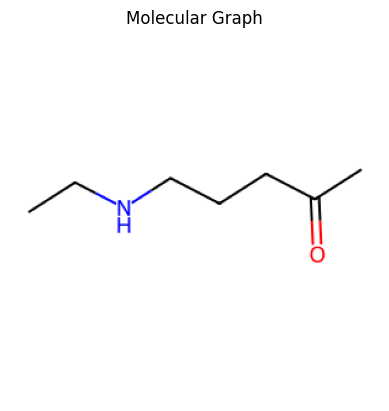

O=CCOC1N=C1C=O


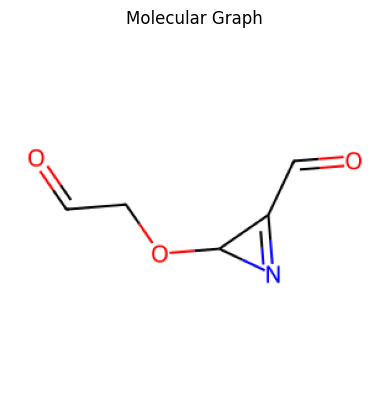

CC1CC1C(C#N)C#N


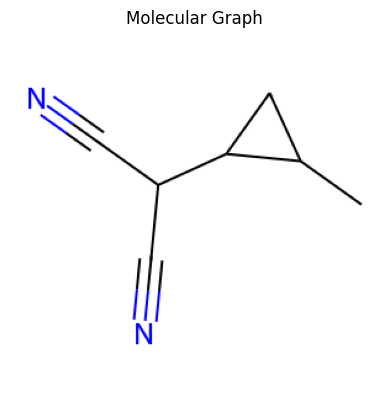

CC=C(CCCC)CC


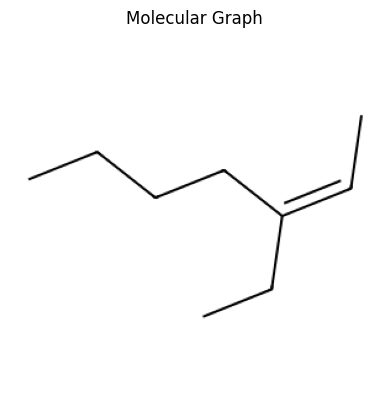

OC(O)CCCNC#N


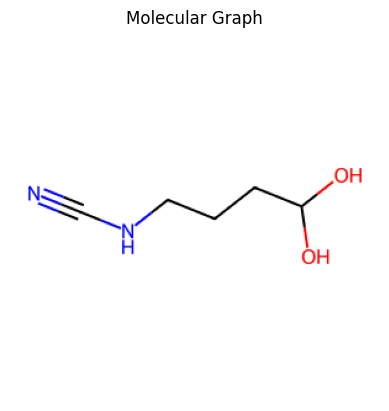

CCCCCC(NC)NC=N


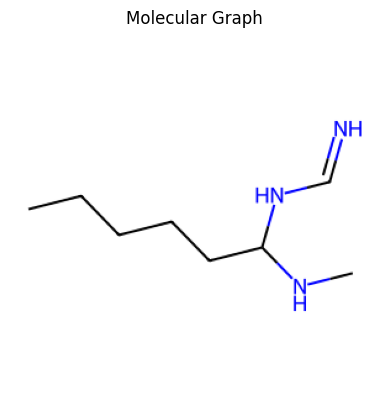

OCC1(O)NC(=O)C1O


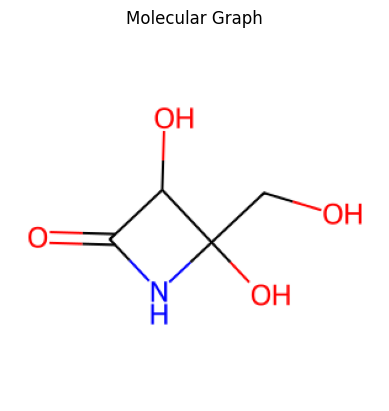

N=COCCC(O)C=O


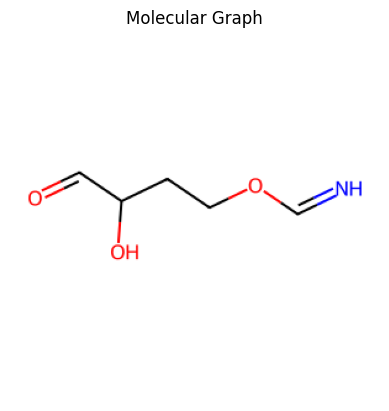

CC(CC)CCCCC


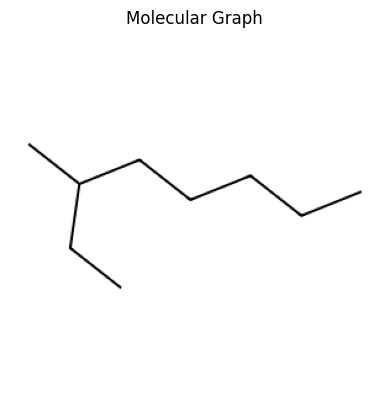

NC(=O)C12CC3CC1C23


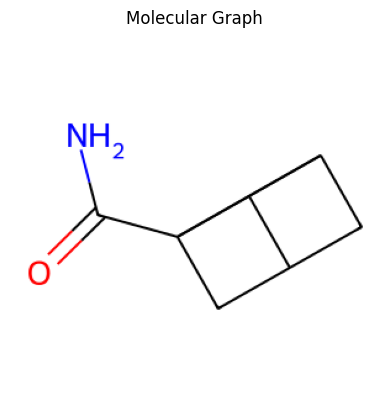

CCCCCCNC(=O)C#N


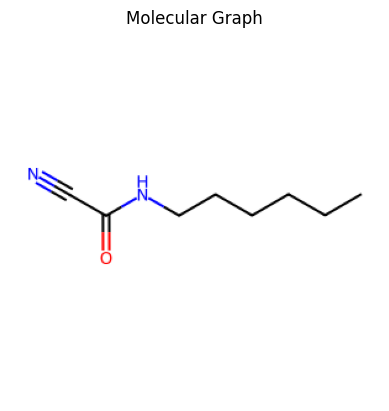

N=COCC1C2C3CNC3C12


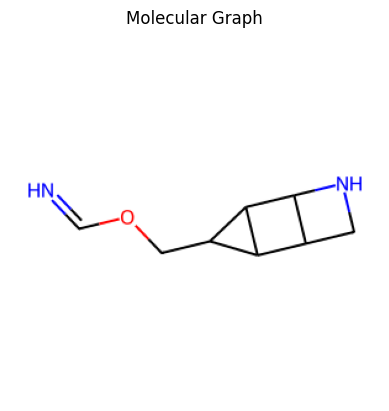

CCN(CC)CO


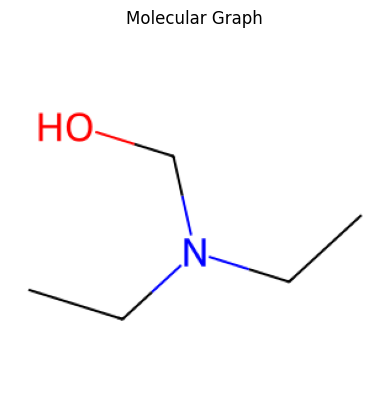

CNCCCCC=O


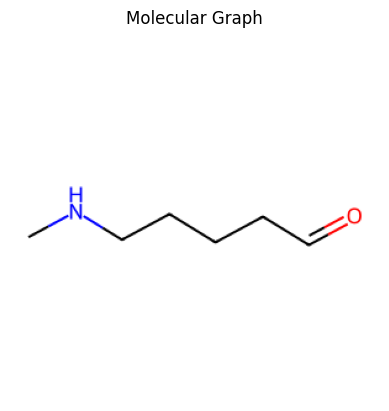

CN1CNC1O


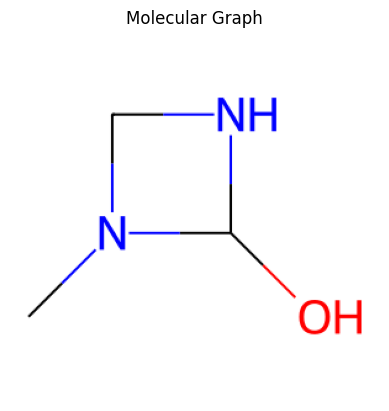

O=CCCOCCCCC


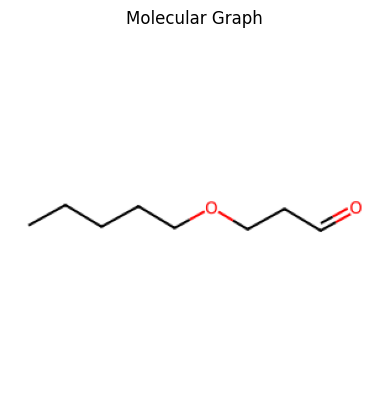

C=CC=CC=NOC


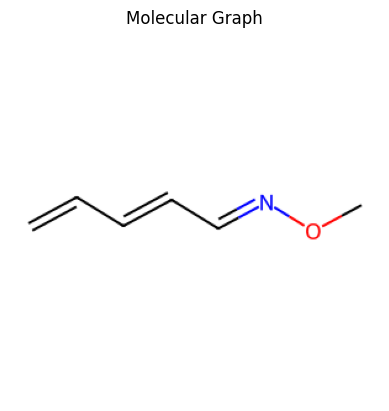

N#CCCNCN


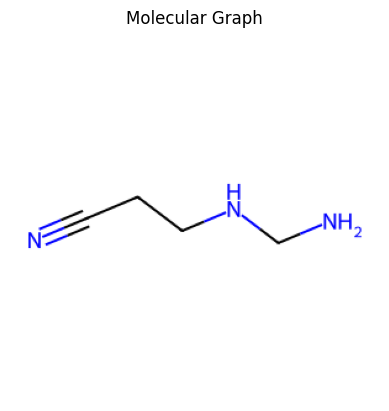

CCC1CCCC=C1


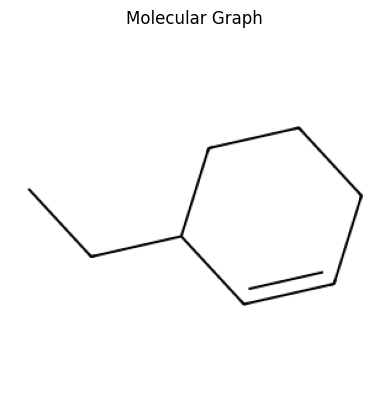

C1C(=O)NC1C=O


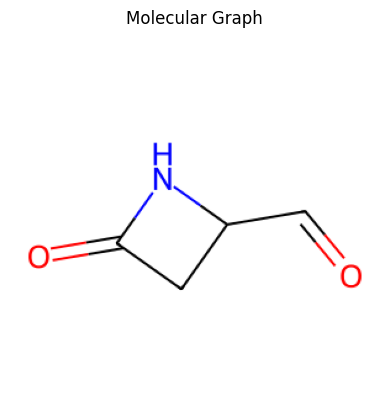

C1C(C23)C2C13C#N


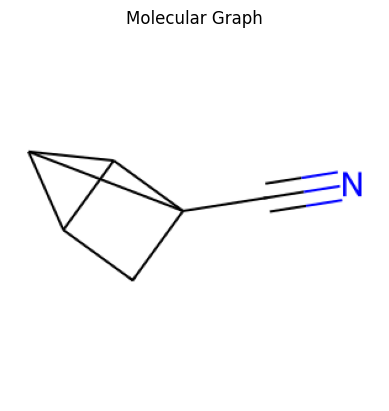

O1CC2NC1(CC)C2=O


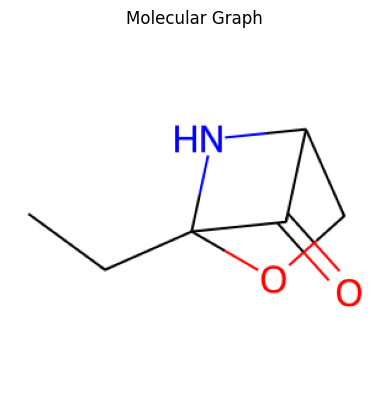

CCC12CCC1N2CC


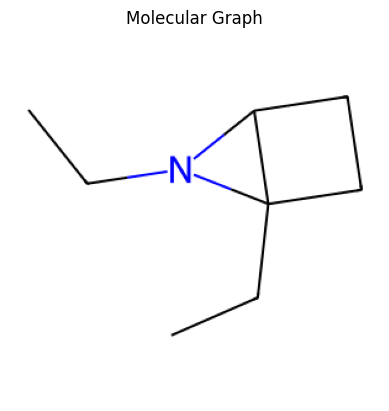

OC12C3C1CC3C2C#N


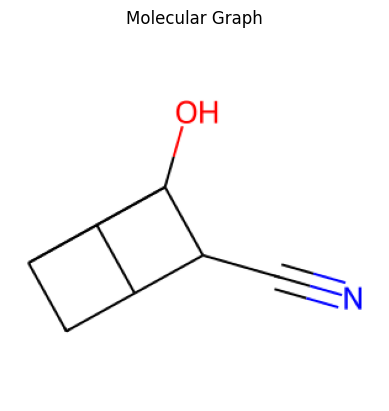

CNCOC1CC1C


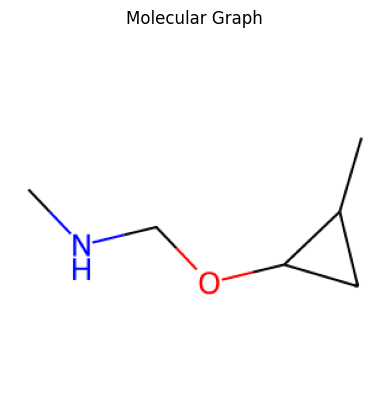

O=C1CCNC1CCC


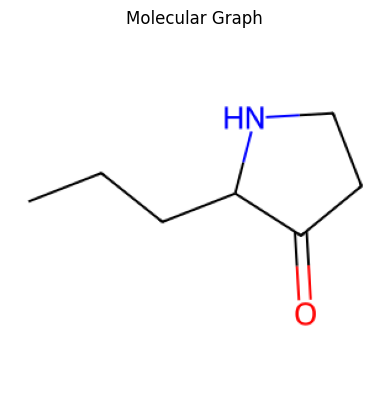

CN=CNC(=NCC)C


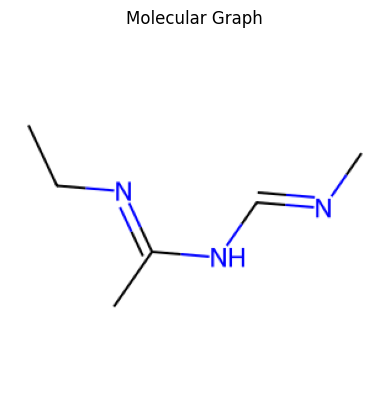

CCCC(C)(C=O)C#N


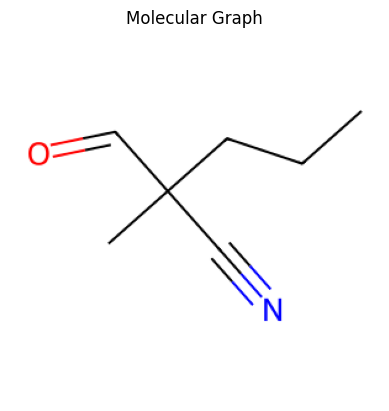

CNCC1NC1(C2)CO2


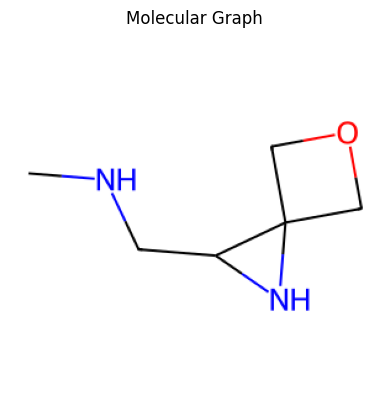

CCC=CCCN=CNCO


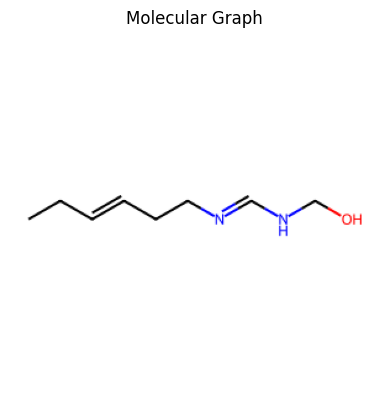

C1CC(C)N1C=O


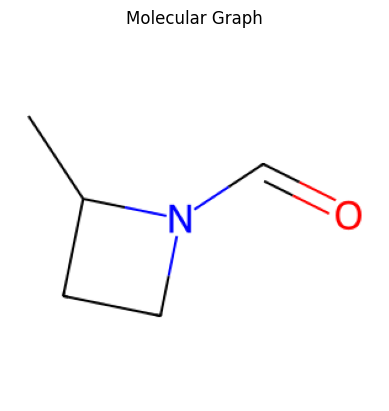

OC(CCC)C1C=CN1


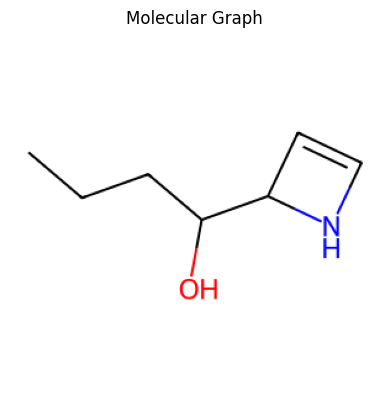

OCCC1C2CC=NNC1N2


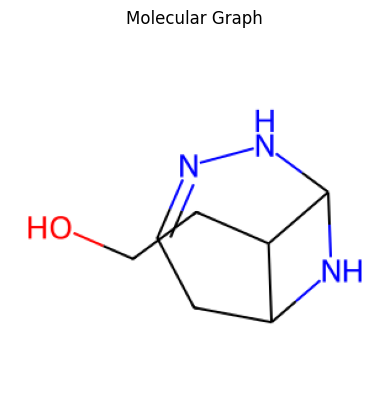

OCC1N2CC2(C)CN1


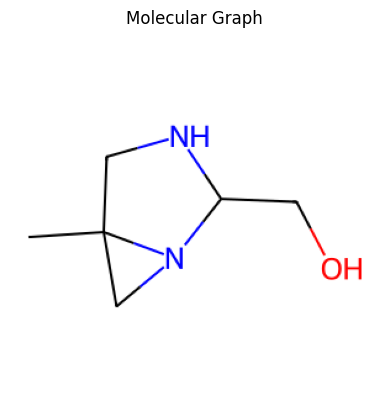

OCCN=COC(=N)O


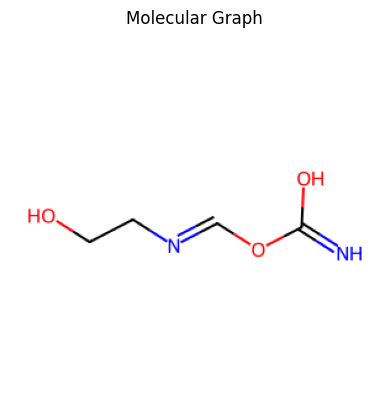

CNC=C(C)OOCC


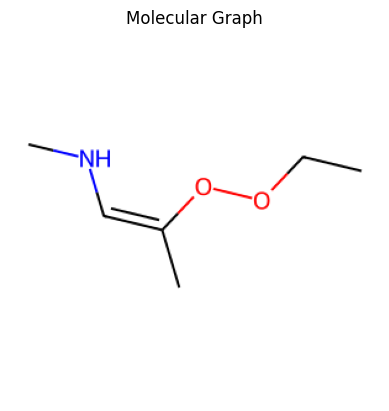

CNC12COCC1OC2


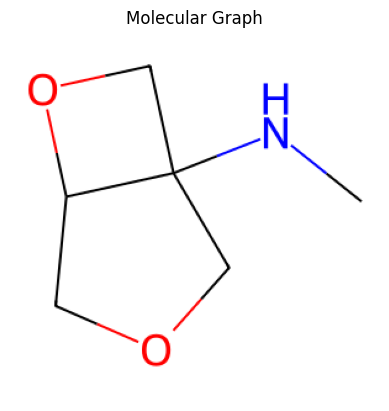

CNC=CCCOCCOC


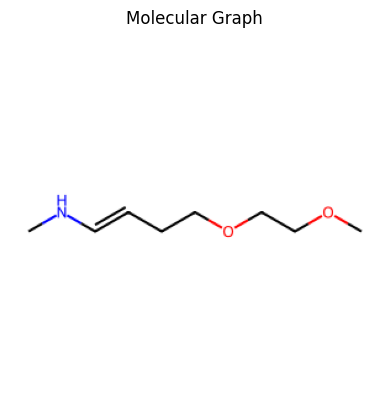

OCC1(C2)C2CN1


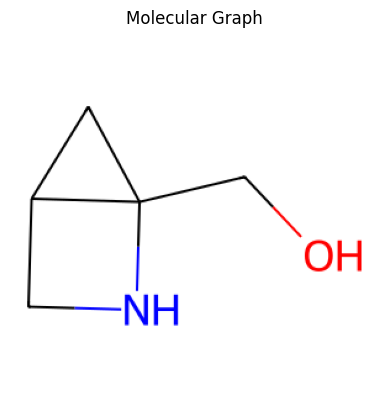

CCC(C)CCCC=O


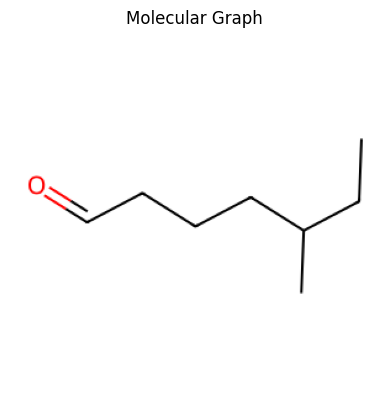

C12NCCC1=C2


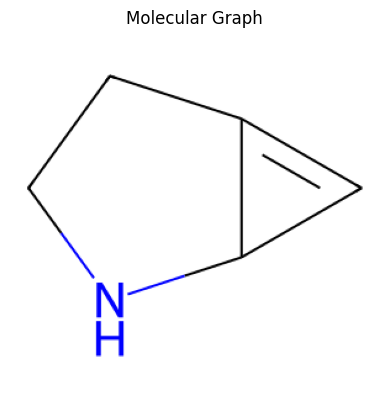

OCC#N


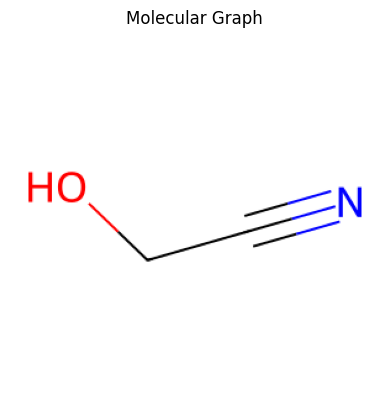

C1OC(C)N=C1


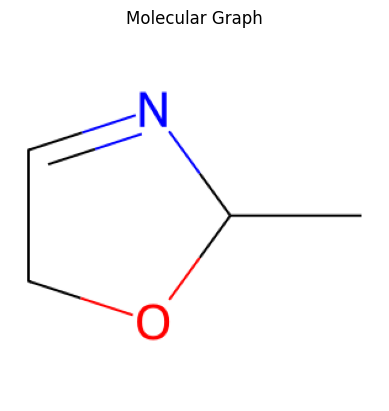

CC1C=CC=C1C


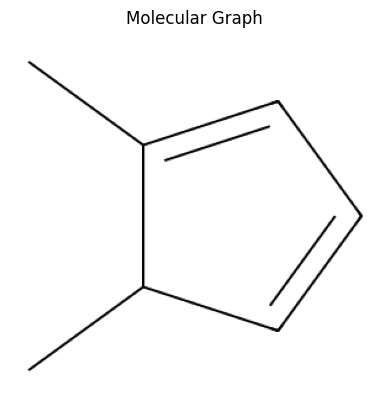

N=CCCCC=O


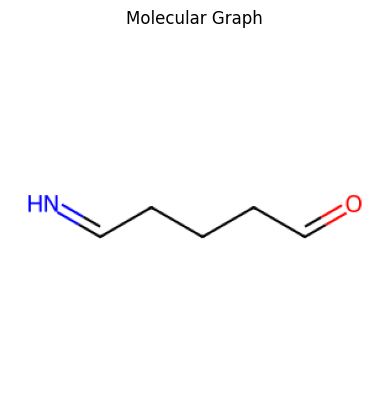

NC(=O)CCC=C=O


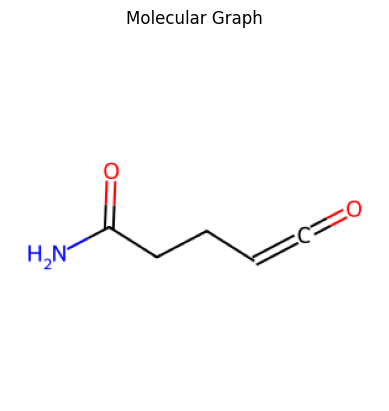

CCCCCCC1=CN=NO1


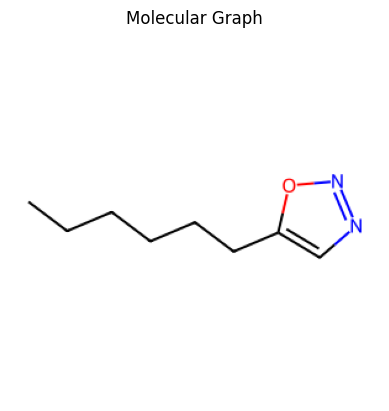

C1CC1CCCOC#N


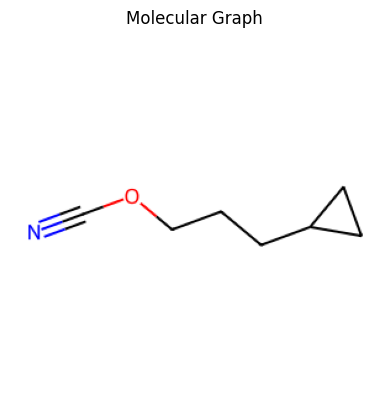

NC(=O)NCCCCNC=O


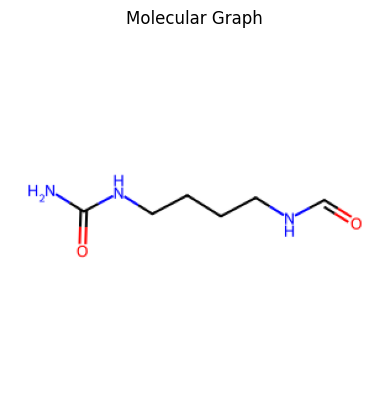

C=CNCC1CC1C=O


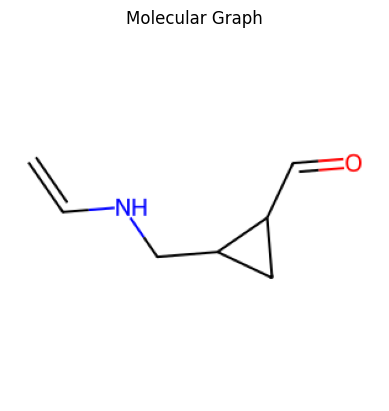

CCCC1CC(O)C1


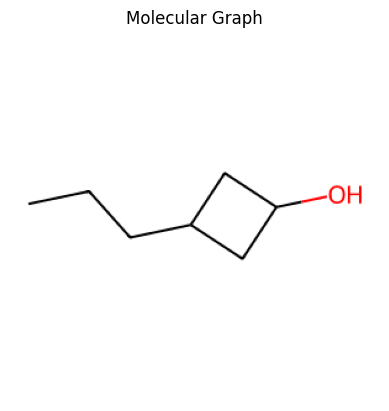

O=CNC1OC1C


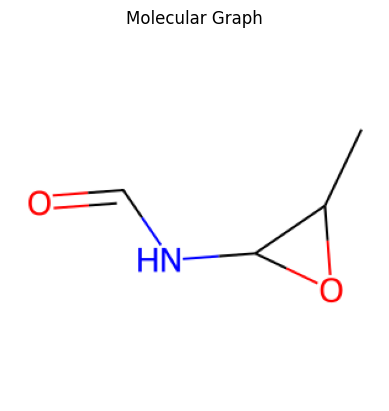

CC1C(O)NC1(C)C#C


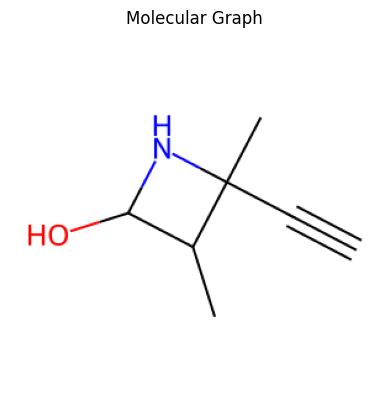

CNC1=CCCO1


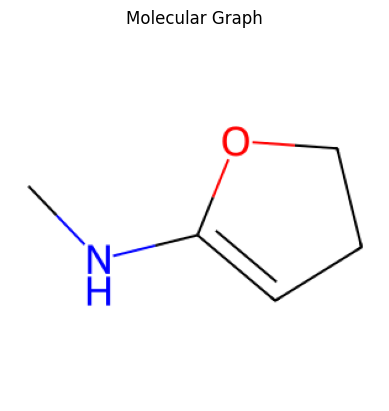

C=1C2CN2C=1COC#N


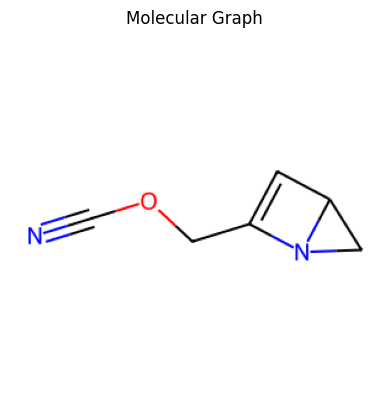

CCN=CCC=C


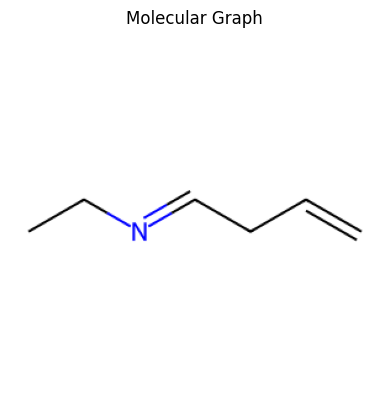

C=1C(O)CC=1


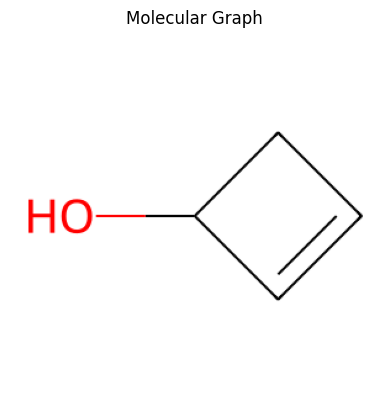

CCCC(=NC)CN


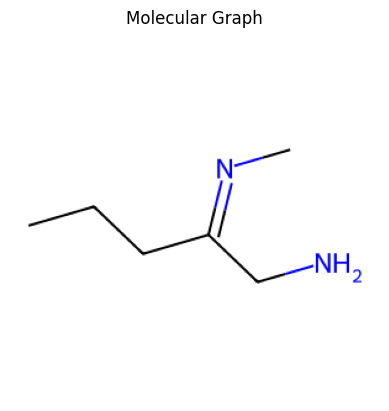

CCCC=C=O


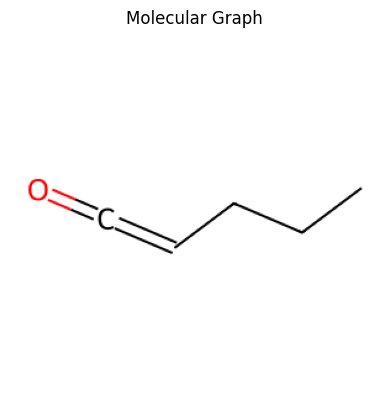

O1C2CC#COC12C


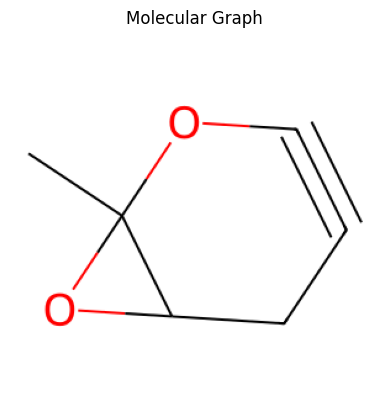

C=C(CC)CNC


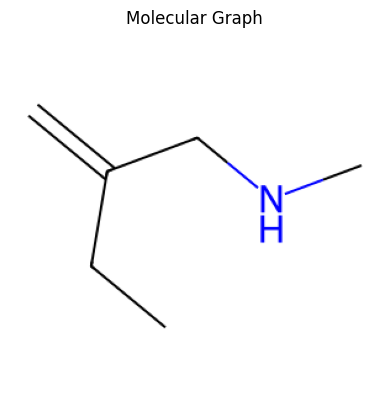

OCC1(O)CCCC=N1


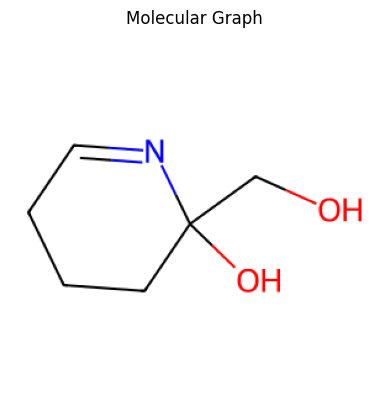

CCCOCOCC=O


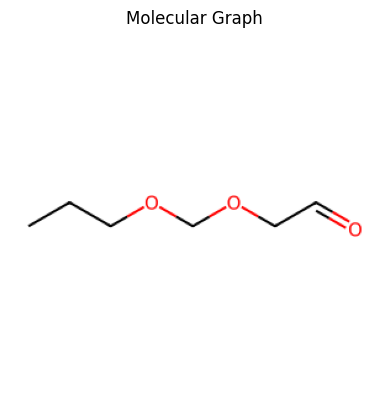

COCCCCC(C1)C1=O


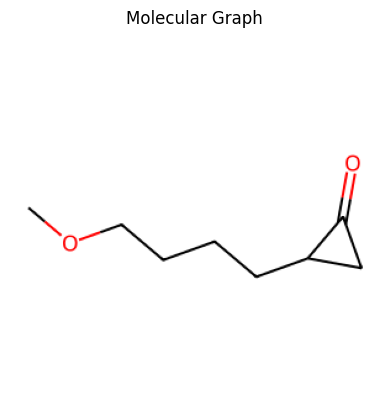

CC1C=C(C)O1


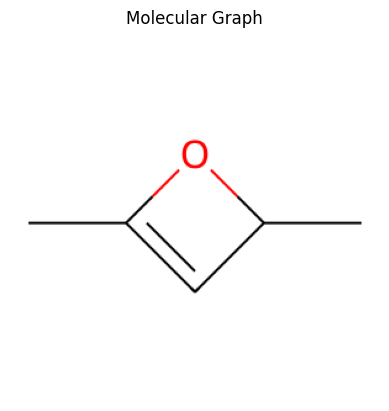

CC(CCC)CCC#N


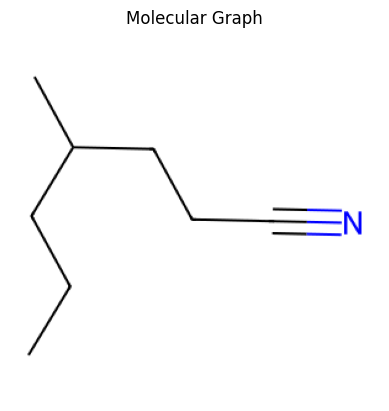

CC1C(C)CCC1C


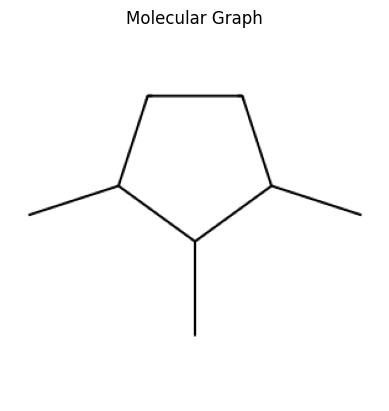

OOCN=C=C=O


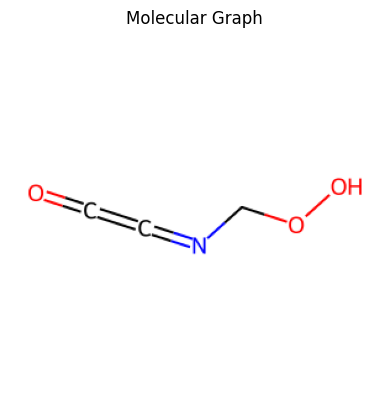

C=1C(CCC)(C=1)N


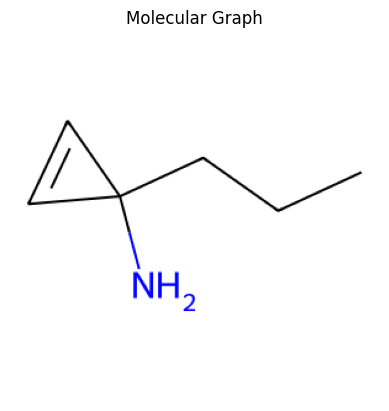

CC(=O)C=CCC=O


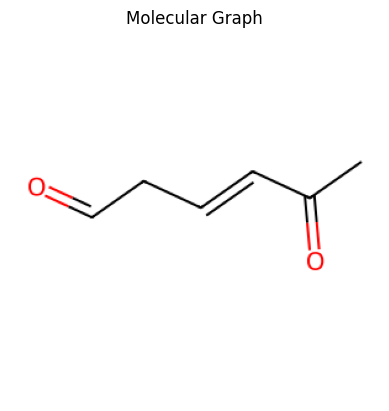

C1N=C1C


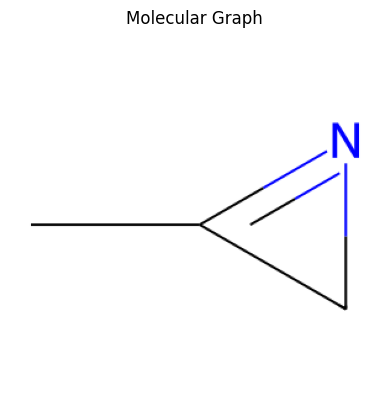

CC1CCC=COC1=N


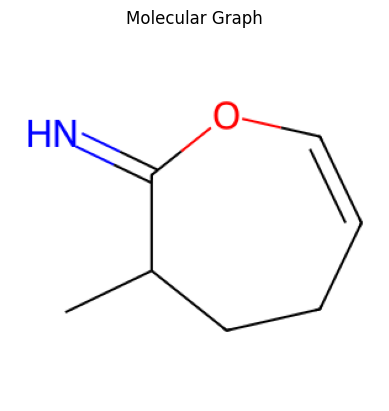

CC=CC=COCCN1CN1


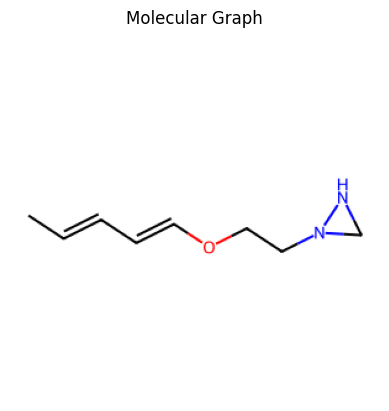

CC(=O)CCCC=O


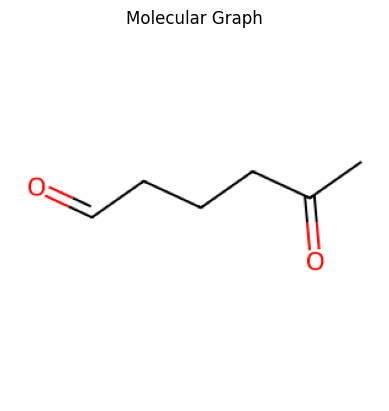

CC(=O)CCCN=C=N


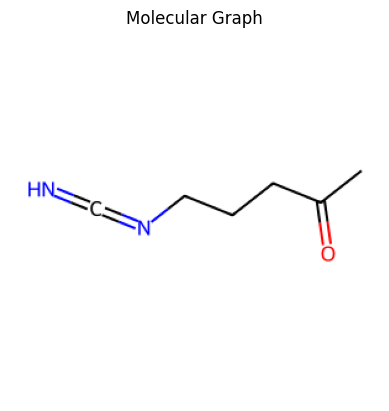

C1CN(N)C1C=O


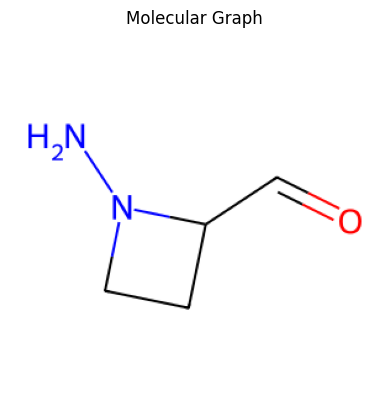

CC=CC1CCCN1C(N)=O


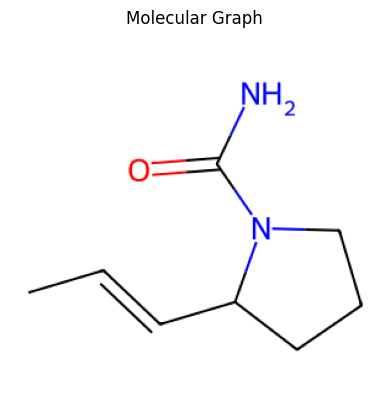

O=C(C)C1CCCC1=O


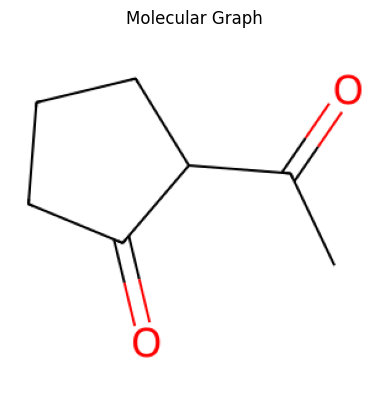

CCCNCOCCN=C=O


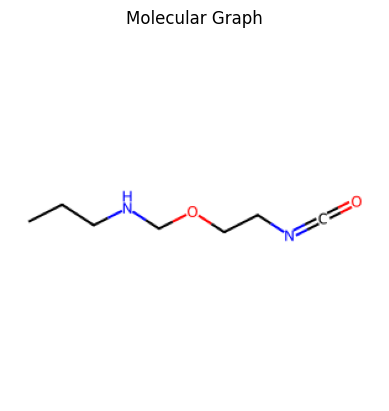

CNCOCCC1OCOC1


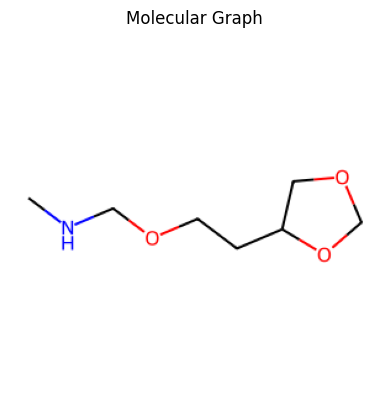

O=C1C=CCCO1


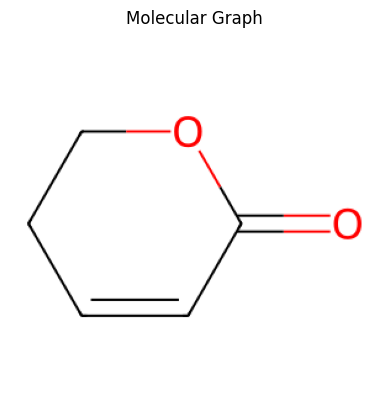

C1OC(O)CC1N


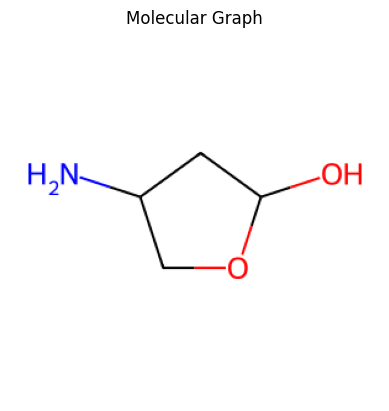

CCC(C)CCOC#N


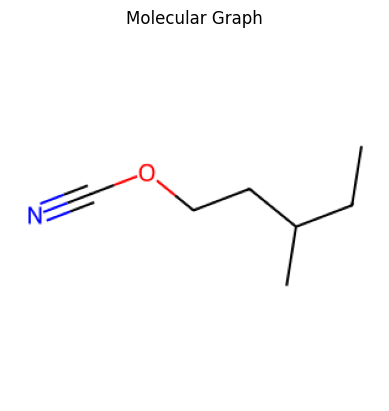

CCCCCC=C=O


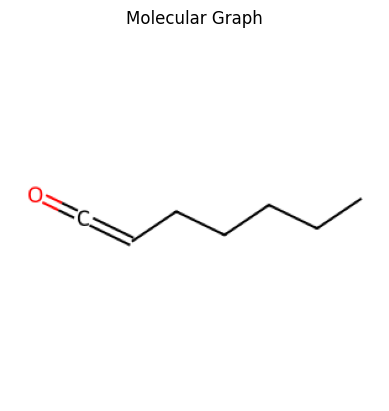

COOCCOCC=O


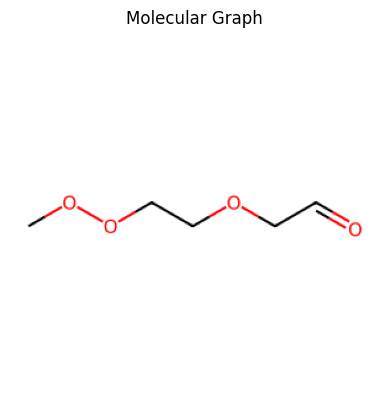

NC(=O)CCCCC#N


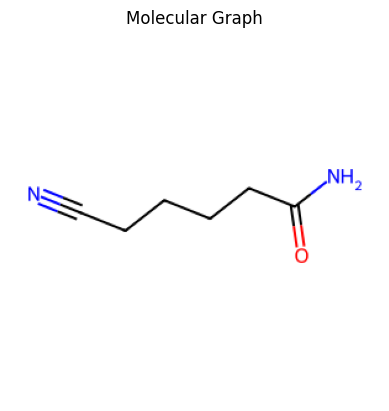

CCC=CC1CNCOC1C


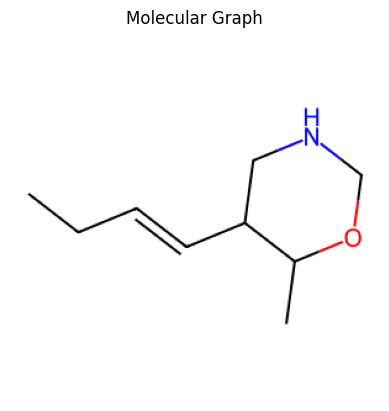

C1N=COC=C1CC


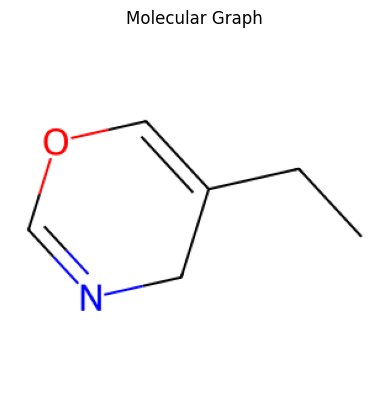

CNC=CC=NOC=O


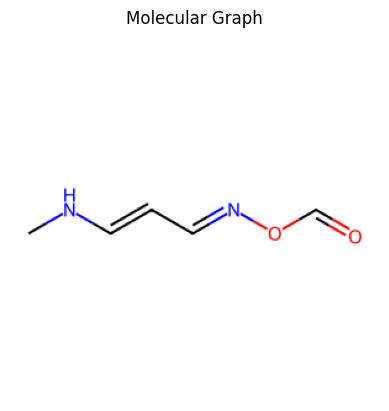

CCOC(C)CCCC=C


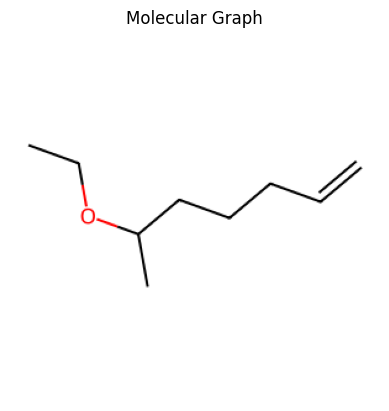

O=CCCC1CC1


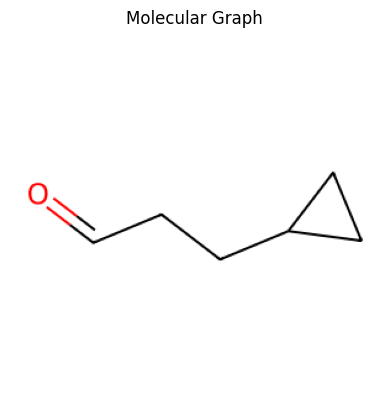

OCCOCCCC#N


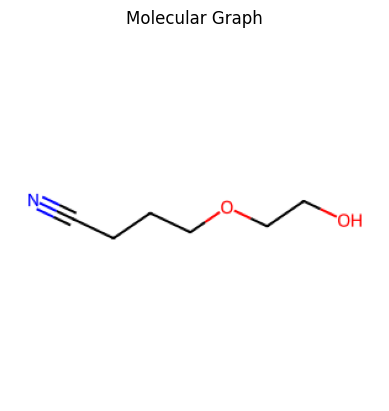

CC1OC1CCCCCC#N


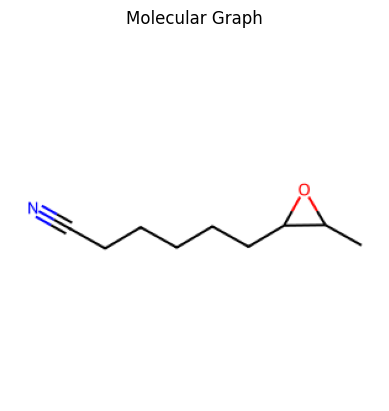

In [13]:
from rdkit import Chem
from rdkit.Chem import Draw
import matplotlib.pyplot as plt

def visualize_smiles(smiles_str):
    """
    Convert a SMILES string to an RDKit molecule and visualize it.
    
    Args:
        smiles_str (str): The SMILES string to visualize.
    """
    # Convert SMILES to an RDKit molecule
    mol = Chem.MolFromSmiles(smiles_str)
    if mol is None:
        print("Invalid SMILES string.")
        return
    
    # Option 1: Using MolToImage to create a PIL image and display it with matplotlib
    img = Draw.MolToImage(mol, size=(300, 300))
    plt.imshow(img)
    plt.axis('off')
    plt.title("Molecular Graph")
    plt.show()

for i, smi in enumerate(generated_smiles_list, 1):
    print(smi)
    visualize_smiles(smi)


In [14]:
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs

def measure_uniqueness(smiles_list):
    """
    Calculates the fraction of unique SMILES.
    
    Args:
        smiles_list (list of str): A list of SMILES strings.
    
    Returns:
        float: The fraction of unique SMILES in the list.
    """
    # Filter out invalid SMILES (None after parsing)
    valid_smiles = []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            valid_smiles.append(Chem.MolToSmiles(mol, isomericSmiles=True))
    # Convert to set to remove duplicates
    unique_smiles = set(valid_smiles)
    if len(valid_smiles) == 0:
        return 0.0
    return len(unique_smiles) / len(valid_smiles)

def measure_diversity(smiles_list, radius=2, nBits=1024):
    """
    Computes the average pairwise Tanimoto distance (1 - similarity) among molecules.
    A higher average distance indicates higher diversity.
    
    Args:
        smiles_list (list of str): A list of SMILES strings.
        radius (int): Radius parameter for Morgan fingerprint.
        nBits (int): Size of the fingerprint bit vector.
    
    Returns:
        float: Average pairwise Tanimoto distance (1 - similarity).
    """
    # Generate fingerprints for all valid SMILES
    fps = []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nBits)
            fps.append(fp)
    
    if len(fps) < 2:
        # Not enough molecules to compare
        return 0.0
    
    # Compute pairwise Tanimoto similarities
    similarities = []
    for i in range(len(fps)):
        for j in range(i + 1, len(fps)):
            sim = DataStructs.TanimotoSimilarity(fps[i], fps[j])
            similarities.append(sim)
    
    # Convert similarity to distance = 1 - similarity
    distances = [1 - sim for sim in similarities]
    
    # Return the average distance
    return np.mean(distances)



uniqueness = measure_uniqueness(generated_smiles_list)
diversity = measure_diversity(generated_smiles_list, radius=2, nBits=1024)

print(f"Uniqueness: {uniqueness:.2f}")
print(f"Average Pairwise Tanimoto Distance: {diversity:.3f}")

Uniqueness: 1.00
Average Pairwise Tanimoto Distance: 0.918


[20:01:14] DEPRECATION WARNING: please use MorganGenerator
[20:01:14] DEPRECATION WARNING: please use MorganGenerator
[20:01:14] DEPRECATION WARNING: please use MorganGenerator
[20:01:14] DEPRECATION WARNING: please use MorganGenerator
[20:01:14] DEPRECATION WARNING: please use MorganGenerator
[20:01:14] DEPRECATION WARNING: please use MorganGenerator
[20:01:14] DEPRECATION WARNING: please use MorganGenerator
[20:01:14] DEPRECATION WARNING: please use MorganGenerator
[20:01:14] DEPRECATION WARNING: please use MorganGenerator
[20:01:14] DEPRECATION WARNING: please use MorganGenerator
[20:01:14] DEPRECATION WARNING: please use MorganGenerator
[20:01:14] DEPRECATION WARNING: please use MorganGenerator
[20:01:14] DEPRECATION WARNING: please use MorganGenerator
[20:01:14] DEPRECATION WARNING: please use MorganGenerator
[20:01:14] DEPRECATION WARNING: please use MorganGenerator
[20:01:14] DEPRECATION WARNING: please use MorganGenerator
[20:01:14] DEPRECATION WARNING: please use MorganGenerat